In [1]:
import pandas as pd

session_mapping = pd.read_json("../data/core/session_mapping.json")
annotated_misalignments = pd.read_json("../data/core/annotated_misalignments.json")

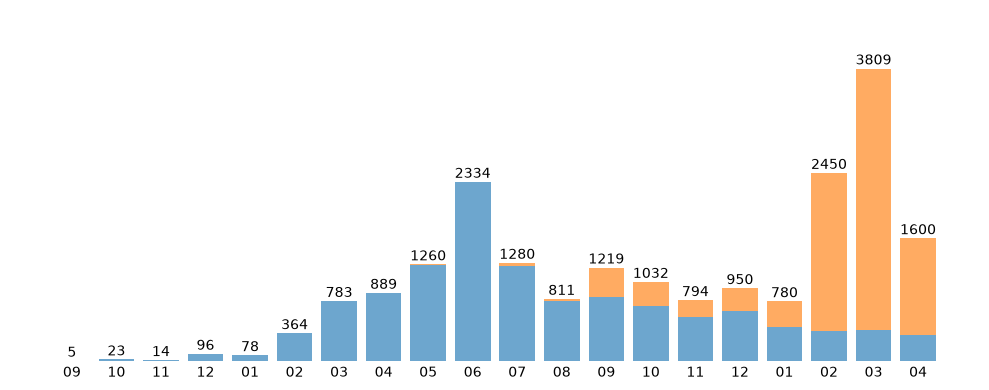

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = session_mapping.copy()
df["session_timestamp"] = pd.to_datetime(
    df["session_timestamp"], utc=True, errors="coerce"
)
df["month"] = df["session_timestamp"].dt.tz_convert(None).dt.to_period("M")

pivot = df.groupby(["month", "session_type"]).size().unstack(fill_value=0).sort_index()
for col in ["IDE", "CLI"]:
    if col not in pivot.columns:
        pivot[col] = 0

# month_labels = [str(m) for m in pivot.index]
month_labels = [str(m)[-2:] for m in pivot.index]
ide_vals = pivot["IDE"].values
cli_vals = pivot["CLI"].values
x = np.arange(len(month_labels))
totals = ide_vals + cli_vals

fig, ax = plt.subplots(figsize=(10, 4))

ax.bar(x, ide_vals, alpha=0.65, label="IDE")
ax.bar(x, cli_vals, bottom=ide_vals, alpha=0.65, label="CLI")

# Count labels on top
for i, total in enumerate(totals):
    if total > 0:
        ax.text(
            x[i],
            total + 10,
            f"{int(total)}",
            ha="center",
            va="bottom",
            fontsize=10,
        )

for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_yticks([])
ax.tick_params(axis="x", length=0)
ax.set_xticks(x)
ax.set_xticklabels(month_labels, fontsize=10)
ax.set_ylim(0, totals.max() * 1.2)

plt.tight_layout()
plt.savefig("results/dataset_timeline.svg", bbox_inches="tight", format="svg")
plt.show()

In [3]:
df = annotated_misalignments.copy()
df["session_timestamp"] = pd.to_datetime(df["session_timestamp"], errors="coerce")
df = df.dropna(subset=["session_timestamp"])
monthly_misalignment_counts = (
    df.assign(month=df["session_timestamp"].dt.to_period("M").dt.to_timestamp())
    .groupby("month")
    .size()
    .rename("n_misalignments")
    .to_frame()
)

monthly_misalignment_counts

,n_misalignments
month,
2024-09-01,1
2024-10-01,34
2024-11-01,28
2024-12-01,96
2025-01-01,87
2025-02-01,400
2025-03-01,861
2025-04-01,977
2025-05-01,1231


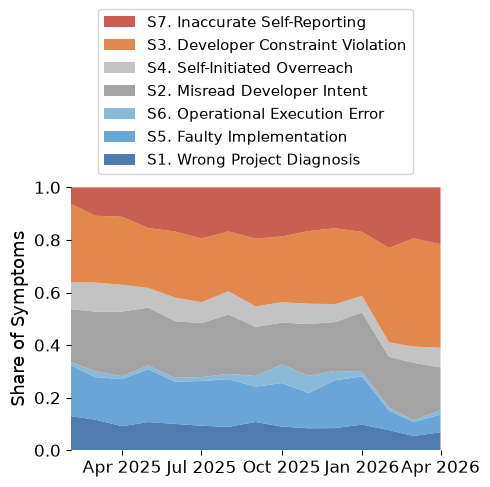

In [4]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
from table_utils import SYMPTOM_NAMES

symptom_order = ["S1", "S5", "S6", "S2", "S4", "S3", "S7"]

color_map = {
    "S1": "#3b6ea5",
    "S5": "#5a9bd4",
    "S6": "#7fb3d5",
    "S2": "#999999",
    "S4": "#bdbdbd",
    "S3": "#e07b39",
    "S7": "#c44e3d",
}

df = annotated_misalignments.copy()
df["session_timestamp"] = pd.to_datetime(df["session_timestamp"], errors="coerce")
df = df.dropna(subset=["session_timestamp"])
df = df[df["session_timestamp"] >= "2025-02-01"]

# Group by year-month string, then convert index to real datetime at the end
df["month_str"] = df["session_timestamp"].dt.strftime("%Y-%m")

long_df = df.melt(
    id_vars=["month_str"],
    value_vars=symptom_order,
    var_name="symptom",
    value_name="present",
)
long_df = long_df[long_df["present"]]

monthly_counts = (
    long_df.groupby(["month_str", "symptom"]).size().unstack(fill_value=0).sort_index()
)
monthly_share = monthly_counts.div(monthly_counts.sum(axis=1), axis=0)
monthly_share = monthly_share.reindex(columns=symptom_order, fill_value=0)

# Convert string index → proper datetime
x = pd.to_datetime([s + "-01" for s in monthly_share.index])
x_num = mdates.date2num(x)  # matplotlib numeric dates

fig, ax = plt.subplots(figsize=(5, 5))

# Use stackplot with numeric x — fully bypasses pandas date-axis issues
ax.stackplot(
    x_num,
    [monthly_share[s].values for s in symptom_order],
    colors=[color_map[s] for s in symptom_order],
    alpha=0.9,
    labels=[f"{s}. {SYMPTOM_NAMES[s]}" for s in symptom_order],
)

ax.set_ylabel("Share of Symptoms", fontsize=13)
ax.set_ylim(0, 1)
ax.set_xlim(x_num[0], x_num[-1])

# x-axis: 5 explicit ticks
tick_dates = pd.to_datetime(
    ["2025-04-01", "2025-07-01", "2025-10-01", "2026-01-01", "2026-04-01"]
)
ax.set_xticks(mdates.date2num(tick_dates))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.tick_params(axis="x", labelsize=12)
ax.tick_params(axis="y", labelsize=12)

handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles[::-1],
    labels[::-1],
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),
    fontsize=11,
    ncols=1,
)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig("results/symptom_timeline.pdf", bbox_inches="tight")
plt.show()

In [5]:
import pandas as pd
from scipy.stats import linregress
from table_utils import SYMPTOM_NAMES

symptom_cols = ["S1", "S2", "S3", "S4", "S5", "S6", "S7", "S8"]

df = annotated_misalignments.copy()
df["session_timestamp"] = pd.to_datetime(df["session_timestamp"], errors="coerce")
df = df.dropna(subset=["session_timestamp"])
df = df[df["session_timestamp"] >= "2025-02-01"]
df = df[df["session_type"].isin(["IDE", "CLI"])]


def fit_symptom_trends(frame, group_name):
    long_df = frame.assign(day=frame["session_timestamp"].dt.floor("D")).melt(
        id_vars=["day"],
        value_vars=symptom_cols,
        var_name="symptom",
        value_name="present",
    )
    long_df = long_df[long_df["present"]]

    daily_counts = (
        long_df.groupby(["day", "symptom"]).size().unstack(fill_value=0).sort_index()
    )

    if daily_counts.empty:
        return pd.DataFrame(
            columns=["trend", "slope", "p_value", "r_value"],
            index=pd.Index([], name="symptom"),
        )

    daily_share = daily_counts.div(daily_counts.sum(axis=1), axis=0)
    daily_share["t"] = (daily_share.index - daily_share.index.min()).days

    results = []
    for symptom in symptom_cols:
        tmp = daily_share[[symptom, "t"]].dropna()
        if len(tmp) < 2 or tmp["t"].nunique() < 2:
            fit = None
            trend = "NA"
            slope = float("nan")
            p_value = float("nan")
            r_value = float("nan")
        else:
            fit = linregress(tmp["t"], tmp[symptom])
            trend = "up" if fit.slope > 0 else "down"
            slope = fit.slope
            p_value = fit.pvalue
            r_value = fit.rvalue

        results.append(
            {
                "session_type": group_name,
                "symptom": symptom,
                "trend": trend,
                "slope": slope,
                "p_value": p_value,
                "r_value": r_value,
            }
        )

    return pd.DataFrame(results).set_index(["session_type", "symptom"])


results_df = pd.concat(
    [
        fit_symptom_trends(df, "Overall"),
        fit_symptom_trends(df[df["session_type"] == "IDE"], "IDE"),
        fit_symptom_trends(df[df["session_type"] == "CLI"], "CLI"),
    ]
).sort_index()

pretty_results = results_df.copy()
pretty_results.index = pd.MultiIndex.from_tuples(
    [(group, f"{code}. {SYMPTOM_NAMES[code]}") for group, code in pretty_results.index],
    names=["session_type", "symptom"],
)
pretty_results["slope"] = pretty_results["slope"].round(6)
pretty_results["p_value"] = pretty_results["p_value"].map(
    lambda x: "NA" if pd.isna(x) else f"{x:.2e}"
)
pretty_results["r_value"] = pretty_results["r_value"].round(3)

pretty_results[["trend", "slope", "p_value", "r_value"]]

trend     slope   p_value  \
session_type symptom                                                        
CLI          S1. Wrong Project Diagnosis         down -0.000037  5.99e-01   
             S2. Misread Developer Intent          up  0.000120  3.25e-01   
             S3. Developer Constraint Violation    up  0.000351  4.94e-02   
             S4. Self-Initiated Overreach        down -0.000064  3.51e-01   
             S5. Faulty Implementation           down -0.000065  5.03e-01   
             S6. Operational Execution Error     down -0.000332  3.65e-04   
             S7. Inaccurate Self-Reporting         up  0.000024  8.55e-01   
             S8. Other / Emerging                  up  0.000003  6.09e-01   
IDE          S1. Wrong Project Diagnosis         down -0.000144  6.82e-06   
             S2. Misread Developer Intent          up  0.000091  1.05e-01   
             S3. Developer Constraint Violation    up  0.000210  3.61e-04   
             S4. Self-Initiated Overreach        down -0.000090  1.25e-03   
             S5. Faulty Implementation           down -0.000148  1.23e-03   
             S6. Operational Execution Error     down -0.000005  7.43e-01   
             S7. Inaccurate Self-Reporting         up  0.000065  7.47e-02   
             S8. Other / Emerging                  up  0.000020  1.10e-02   
Overall      S1. Wrong Project Diagnosis         down -0.000124  2.51e-08   
             S2. Misread Developer Intent        down -0.000109  7.03e-04   
             S3. Developer Constraint Violation    up  0.000322  4.80e-14   
             S4. Self-Initiated Overreach        down -0.000108  7.24e-08   
             S5. Faulty Implementation           down -0.000249  6.34e-12   
             S6. Operational Execution Error       up  0.000025  1.17e-01   
             S7. Inaccurate Self-Reporting         up  0.000235  3.16e-13   
             S8. Other / Emerging                  up  0.000008  6.28e-02   

                                                 r_value  
session_type symptom                                      
CLI          S1. Wrong Project Diagnosis          -0.034  
             S2. Misread Developer Intent          0.064  
             S3. Developer Constraint Violation    0.126  
             S4. Self-Initiated Overreach         -0.060  
             S5. Faulty Implementation            -0.043  
             S6. Operational Execution Error      -0.227  
             S7. Inaccurate Self-Reporting         0.012  
             S8. Other / Emerging                  0.033  
IDE          S1. Wrong Project Diagnosis          -0.215  
             S2. Misread Developer Intent          0.078  
             S3. Developer Constraint Violation    0.171  
             S4. Self-Initiated Overreach         -0.155  
             S5. Faulty Implementation            -0.155  
             S6. Operational Execution Error      -0.016  
             S7. Inaccurate Self-Reporting         0.086  
             S8. Other / Emerging                  0.122  
Overall      S1. Wrong Project Diagnosis          -0.259  
             S2. Misread Developer Intent         -0.159  
             S3. Developer Constraint Violation    0.345  
             S4. Self-Initiated Overreach         -0.250  
             S5. Faulty Implementation            -0.316  
             S6. Operational Execution Error       0.074  
             S7. Inaccurate Self-Reporting         0.334  
             S8. Other / Emerging                  0.088

In [6]:
import pandas as pd
from scipy.stats import linregress
from table_utils import SYMPTOM_NAMES

symptom_cols = ["S1", "S2", "S3", "S4", "S5", "S6", "S7", "S8"]

sessions = session_mapping.copy()
sessions["session_timestamp"] = pd.to_datetime(
    sessions["session_timestamp"], errors="coerce"
)
sessions = sessions.dropna(subset=["session_timestamp"])
sessions = sessions[sessions["session_timestamp"] >= "2025-02-01"]

mis = annotated_misalignments.copy()
mis["session_timestamp"] = pd.to_datetime(mis["session_timestamp"], errors="coerce")
mis = mis.dropna(subset=["session_timestamp"])
mis = mis[mis["session_timestamp"] >= "2025-02-01"]

daily_user_turns = (
    sessions.assign(day=sessions["session_timestamp"].dt.floor("D"))
    .groupby("day")["user_turns"]
    .sum()
    .rename("user_turns")
)

daily_total_mis = (
    mis.assign(day=mis["session_timestamp"].dt.floor("D"))
    .groupby("day")
    .size()
    .rename("overall")
)

long_df = mis.assign(day=mis["session_timestamp"].dt.floor("D")).melt(
    id_vars=["day"],
    value_vars=symptom_cols,
    var_name="symptom",
    value_name="present",
)

long_df = long_df[long_df["present"]]

daily_symptom_counts = (
    long_df.groupby(["day", "symptom"]).size().unstack(fill_value=0).sort_index()
)

daily_counts = daily_symptom_counts.join(daily_total_mis, how="outer")
daily_rates = daily_counts.join(daily_user_turns, how="outer").fillna(0)
daily_rates = daily_rates[daily_rates["user_turns"] > 0]

results = []

for label in ["overall"] + symptom_cols:
    tmp = daily_rates[[label, "user_turns"]].copy()
    tmp["rate"] = tmp[label] / tmp["user_turns"]
    tmp["t"] = (tmp.index - tmp.index.min()).days

    fit = linregress(tmp["t"], tmp["rate"])

    results.append(
        {
            "label": label,
            "trend": "up" if fit.slope > 0 else "down",
            "slope": fit.slope,
            "p_value": fit.pvalue,
            "r_value": fit.rvalue,
        }
    )

results_df = pd.DataFrame(results).set_index("label")

pretty_results = results_df.copy()
pretty_results.index = [
    "Overall misalignment rate" if x == "overall" else f"{x}. {SYMPTOM_NAMES[x]}"
    for x in pretty_results.index
]
pretty_results["slope"] = pretty_results["slope"].round(6)
pretty_results["p_value"] = pretty_results["p_value"].map(lambda x: f"{x:.2e}")
pretty_results["r_value"] = pretty_results["r_value"].round(3)

pretty_results

,trend,slope,p_value,r_value
Overall misalignment rate,down,-0.000264,7.70e-47,-0.606
S1. Wrong Project Diagnosis,down,-0.000046,1.60e-30,-0.504
S2. Misread Developer Intent,down,-0.000093,6.77e-38,-0.555
S3. Developer Constraint Violation,down,-0.000061,1.12e-11,-0.312
S4. Self-Initiated Overreach,down,-0.000045,3.18e-29,-0.494
S5. Faulty Implementation,down,-0.000086,1.51e-28,-0.489
S6. Operational Execution Error,down,-0.000006,1.97e-03,-0.145
S7. Inaccurate Self-Reporting,down,-0.000018,3.71e-03,-0.136
S8. Other / Emerging,up,0.000000,4.44e-01,0.036
